# 3. Bagging (Bootstraping aggregation)
- **Here we have the same model and trained them on same data.**
- **The variance in data is obtained by taking random sample from it and feed to the models separately thus making them trained differently.**
- **Prediction is same like other ensemble techniques**
- **Random forest is the special case of bagging where the model is decision trees**.

# BOOTSTRAPPING
**SAMPLING IS DONE BY TWO WAYS EITHER WITH OR WOIHOUT REPLACEMENT MEANS DUPLICATION CAN BE POSSIBLE IN WITH REPLACEMENT CASE.TYPES INCLUDE:**
- ROWS SAMPLING
- FEATURE SAMPLING
- COMBINATION SAMPLING

# AGGREGATION
FOR PREDICTION WE SIMPLY COUNT ON THE DEMOCRACY RULE I.E
- **IN CLASSIFICATION SETUP => MAJORITY COUNT**
- **IN REGRESSION SETUP     =>          MEAN VALUE**



---



---



---



# **WHY BAGGING IS USEFUL?**

**IT CAN COVERT THE LOW BIAS AND HIGH VARIANCE ALGORITHUM INTO LOW BIAS AND LOW VARIANCE ALGORITHUM**

# BIAS
WHEN MODEL IS NOT WELL TRAINED ON TRAINING DATA BUT CAN PERFORM WELL ON NEW DATA
# VARIANCE
WHEN MODEL CRAMS THE PATTERN IN TRAINING DATA AND PERFORMS WELL ON TRAINING DATA BUT CANT BE EXCECUTED ON NEW DATA

# BIAS VS VARIANCE (ALWAYS FOLLOWS INDIRECT RELATION)

# IDEAL SCENARION
- LOW BIAS
- LOW VARIANCE

#TYPES OF ALGORITHUM

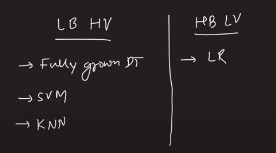


#HOW BAGGING REDUCE THE HIGH VARIANCE TO LOW VARIANCE
Random Forest reduces high variance by using bootstrapped subsamples and random feature selection for training multiple decision trees, then averaging their predictions, which mitigates overfitting and enhances generalization



---



---



# WHEN TO USE?
# **AKWAYS**



---



---



In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('iris.csv')
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
df = df.iloc[:,1:]
df.head()

,sepal.width,petal.length,petal.width,variety
0,3.5,1.4,0.2,Setosa
1,3.0,1.4,0.2,Setosa
2,3.2,1.3,0.2,Setosa
3,3.1,1.5,0.2,Setosa
4,3.6,1.4,0.2,Setosa


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['variety'] = encoder.fit_transform(df['variety'])
df.sample(6)

,sepal.width,petal.length,petal.width,variety
91,3.0,4.6,1.4,1
55,2.8,4.5,1.3,1
141,3.1,5.1,2.3,2
43,3.5,1.6,0.6,0
10,3.7,1.5,0.2,0
40,3.5,1.3,0.3,0


In [11]:
df = df[df['variety'] != 0][['sepal.width','petal.length','variety']]
df.head()

,sepal.width,petal.length,variety
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


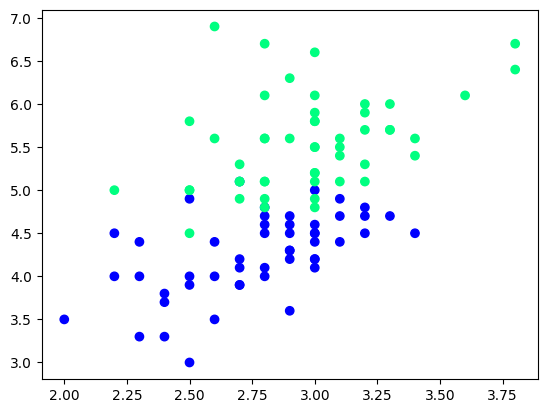

In [14]:
plt.scatter(df['sepal.width'],df['petal.length'],c=df['variety'],cmap='winter')

In [15]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal.width,petal.length,variety
75,3.0,4.4,1
104,3.0,5.8,2
95,3.0,4.2,1
65,3.1,4.4,1
51,3.2,4.5,1
101,2.7,5.1,2
54,2.8,4.6,1
64,2.9,3.6,1
55,2.8,4.5,1
97,2.9,4.3,1


In [17]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,sepal.width,petal.length,variety
103,2.9,5.6,2
92,2.6,4.0,1
132,2.8,5.6,2
76,2.8,4.8,1
50,3.2,4.7,1
51,3.2,4.5,1
97,2.9,4.3,1
126,2.8,4.8,2
81,2.4,3.7,1
78,2.9,4.5,1


In [19]:
df_val

,sepal.width,petal.length,variety
79,2.6,3.5,1
64,2.9,3.6,1
88,3.0,4.1,1
117,3.8,6.7,2
144,3.3,5.7,2


In [20]:
df_test

,sepal.width,petal.length,variety
106,2.5,4.5,2
138,3.0,4.8,2
141,3.1,5.1,2
119,2.2,5.0,2
121,2.8,4.9,2


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# BOOTSTRAPPING

In [22]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal.width,petal.length,variety
126,2.8,4.8,2
76,2.8,4.8,1
78,2.9,4.5,1
103,2.9,5.6,2
103,2.9,5.6,2
132,2.8,5.6,2
76,2.8,4.8,1
76,2.8,4.8,1


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [24]:
dt_bag1 = DecisionTreeClassifier()

In [25]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

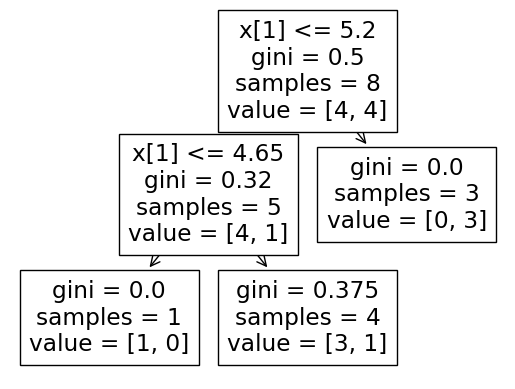

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


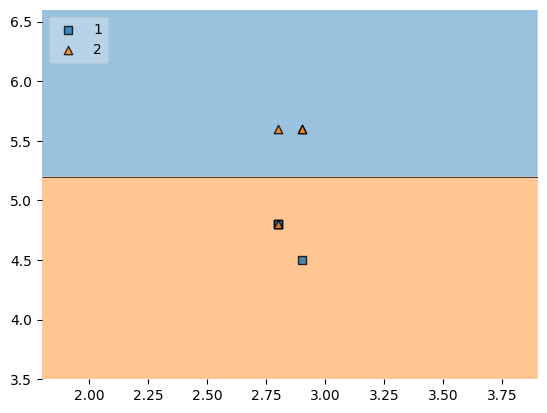

In [26]:
evaluate(dt_bag1,X,y)

In [27]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal.width,petal.length,variety
103,2.9,5.6,2
78,2.9,4.5,1
103,2.9,5.6,2
103,2.9,5.6,2
51,3.2,4.5,1
126,2.8,4.8,2
78,2.9,4.5,1
132,2.8,5.6,2


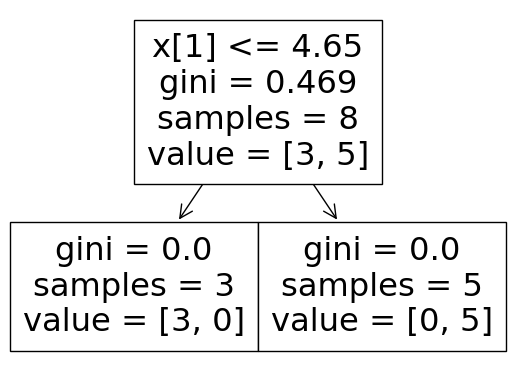

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


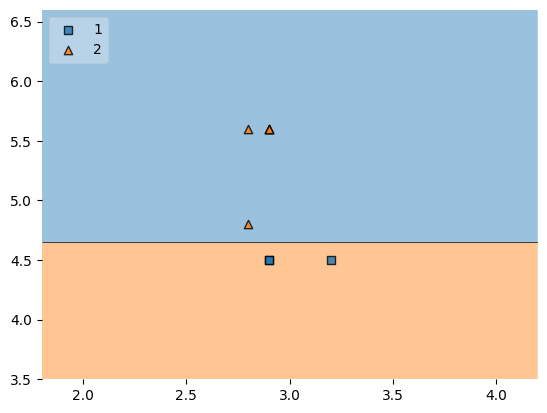

In [28]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal.width,petal.length,variety
132,2.8,5.6,2
81,2.4,3.7,1
51,3.2,4.5,1
97,2.9,4.3,1
97,2.9,4.3,1
78,2.9,4.5,1
76,2.8,4.8,1
78,2.9,4.5,1


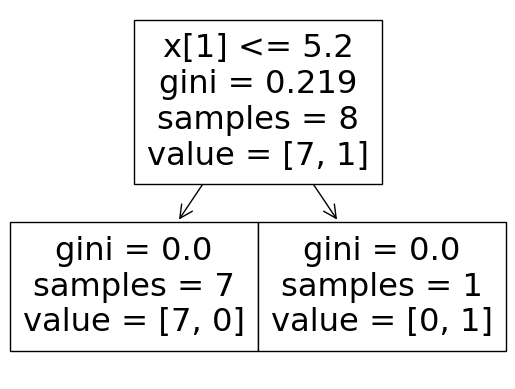

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


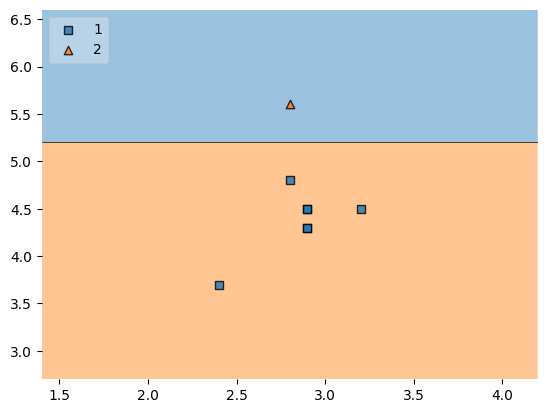

In [30]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# AGGREGATION

In [31]:
df_test

,sepal.width,petal.length,variety
106,2.5,4.5,2
138,3.0,4.8,2
141,3.1,5.1,2
119,2.2,5.0,2
121,2.8,4.9,2


In [32]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [1]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# TYPES

1. BAGGING (ROWS SAMPLING WITH REPLACEMENT)
2. PASTING (ROWS SAMPLING WITHOUT REPLACEMENT)
3. Random Subspaces (FEATURE SAMPLING WITH OR WITHOUT REPLACEMENT)
4. Random Patches (COMBINED SAMPLING)